# CVD Fairness Analysis — XGBoost Baseline
SHAP-based investigation of sex-based disparities in false-negative predictions.

## 1. Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import classification_report, roc_auc_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

## 2. Load Model & Test Data

In [22]:
with open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model = pickle.load(f)

test_df = pd.read_csv("data/test_train_val_sets/cardio_baseline_test.csv")
X_test  = test_df.drop(columns=["cardio", "stratify"])
y_test  = test_df["cardio"]
y_pred  = model.predict(X_test)

female_mask = test_df["gender"].values == 0
male_mask   = test_df["gender"].values == 1

In [23]:
import json

with open("config/dataset_split_sizes.json", "r") as f:
    expected = json.load(f)


assert len(test_df)  == expected["test"],  "Test size mismatch"

print("Dataset sizes validated.")


Dataset sizes validated.


## 3. Fairness Metrics (EOD & Disparate Impact)

In [3]:
from sklearn.metrics import confusion_matrix, recall_score

def get_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "TPR": tp / (tp + fn),   # sensitivity
        "TNR": tn / (tn + fp),   # specificity
        "FPR": fp / (fp + tn),   # false positive rate
        "FNR": fn / (fn + tp),   # false negative rate
        "PPV": tp / (tp + fp),   # precision
    }

f = get_rates(y_test[female_mask], y_pred[female_mask])
m = get_rates(y_test[male_mask],   y_pred[male_mask])

pos_rate_female = y_pred[female_mask].mean()
pos_rate_male   = y_pred[male_mask].mean()

prob_female = model.predict_proba(X_test[female_mask])[:, 1]
prob_male   = model.predict_proba(X_test[male_mask])[:, 1]

# ── Core metrics ──────────────────────────────────────────
print(f"Female Recall (Sensitivity) : {f['TPR']:.4f}")
print(f"Male Recall (Sensitivity)   : {m['TPR']:.4f}")
print(f"Female Specificity          : {f['TNR']:.4f}")
print(f"Male Specificity            : {m['TNR']:.4f}")
print(f"Female Precision            : {f['PPV']:.4f}")
print(f"Male Precision              : {m['PPV']:.4f}")

# ── EOD & DI ──────────────────────────────────────────────
eod = m["TPR"] - f["TPR"]
di  = pos_rate_female / pos_rate_male

print(f"\nPos Rate Female             : {pos_rate_female:.4f}")
print(f"Pos Rate Male               : {pos_rate_male:.4f}")
print(f"EOD (0 = fair)              : {eod:.4f}")
print(f"DI  (1 = fair)              : {di:.4f}")

# ── Equalised Odds ────────────────────────────────────────
print(f"\nEqualised Odds — TPR diff (M-F) : {m['TPR'] - f['TPR']:+.4f}")
print(f"Equalised Odds — FPR diff (M-F) : {m['FPR'] - f['FPR']:+.4f}")
print(f"  (both 0 = equalised odds satisfied)")

# ── Predictive Parity ─────────────────────────────────────
print(f"\nPredictive Parity (precision diff M-F) : {m['PPV'] - f['PPV']:+.4f}  (0 = fair)")

# ── FNR Parity ────────────────────────────────────────────
print(f"FNR Parity (female FNR - male FNR)     : {f['FNR'] - m['FNR']:+.4f}  (+ = women missed more)")

# ── Calibration in the large ─────────────────────────────
actual_rate_f = y_test[female_mask].mean()
actual_rate_m = y_test[male_mask].mean()

print(f"\nCalibration in the Large:")
print(f"Female — mean predicted: {prob_female.mean():.4f}  actual rate: {actual_rate_f:.4f}  diff: {prob_female.mean() - actual_rate_f:+.4f}")
print(f"Male   — mean predicted: {prob_male.mean():.4f}  actual rate: {actual_rate_m:.4f}  diff: {prob_male.mean() - actual_rate_m:+.4f}")

# ── Literature comparison ─────────────────────────────────
print(f"\nLi et al. (2023) EOD range  : 0.131 - 0.136")
print(f"Li et al. (2023) DI range   : 1.535 - 1.587")

Female Recall (Sensitivity) : 0.6989
Male Recall (Sensitivity)   : 0.6805
Female Specificity          : 0.7734
Male Specificity            : 0.7617
Female Precision            : 0.7502
Male Precision              : 0.7402

Pos Rate Female             : 0.4596
Pos Rate Male               : 0.4591
EOD (0 = fair)              : -0.0184
DI  (1 = fair)              : 1.0011

Equalised Odds — TPR diff (M-F) : -0.0184
Equalised Odds — FPR diff (M-F) : +0.0116
  (both 0 = equalised odds satisfied)

Predictive Parity (precision diff M-F) : -0.0100  (0 = fair)
FNR Parity (female FNR - male FNR)     : -0.0184  (+ = women missed more)

Calibration in the Large:
Female — mean predicted: 0.4949  actual rate: 0.4933  diff: +0.0015
Male   — mean predicted: 0.5018  actual rate: 0.4994  diff: +0.0025

Li et al. (2023) EOD range  : 0.131 - 0.136
Li et al. (2023) DI range   : 1.535 - 1.587


## 4. Define Prediction Groups

In [4]:
# Women
fn_mask_female = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
tp_mask_female = (y_test.values == 1) & (y_pred == 1) & (test_df["gender"].values == 0)
tn_mask_female = (y_test.values == 0) & (y_pred == 0) & (test_df["gender"].values == 0)

fn_women = test_df[fn_mask_female].copy()
tp_women = test_df[tp_mask_female].copy()
tn_women = test_df[tn_mask_female].copy()

X_test_female = X_test[female_mask].copy()
y_test_female = y_test.values[female_mask]
y_pred_female = y_pred[female_mask]

# Men
fn_mask_male = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 1)
tp_mask_male = (y_test.values == 1) & (y_pred == 1) & (test_df["gender"].values == 1)
tn_mask_male = (y_test.values == 0) & (y_pred == 0) & (test_df["gender"].values == 1)

fn_men = test_df[fn_mask_male].copy()
tp_men = test_df[tp_mask_male].copy()
tn_men = test_df[tn_mask_male].copy()

X_test_male = X_test[male_mask].copy()
y_test_male = y_test.values[male_mask]
y_pred_male = y_pred[male_mask]

print(f"FN women : {len(fn_women)}  |  TP women : {len(tp_women)}  |  TN women : {len(tn_women)}")
print(f"FN men   : {len(fn_men)}  |  TP men   : {len(tp_men)}  |  TN men   : {len(tn_men)}")

FN women : 1317  |  TP women : 3057  |  TN women : 3474
FN men   : 761  |  TP men   : 1621  |  TN men   : 1819


## 5. Feature Summary: FN vs TP (Women & Men)

In [ ]:
compare_features = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc",
                    "weight", "height", "smoke", "alco", "active"]

for label, fn_grp, tp_grp in [("women", fn_women, tp_women), ("men", fn_men, tp_men)]:
    print(f"\nFalse-negative {label} vs true-positive {label}:")
    print(pd.DataFrame({
        "FN_mean":                fn_grp[compare_features].mean(),
        "TP_mean":                tp_grp[compare_features].mean(),
        "FN_median":              fn_grp[compare_features].median(),
        "TP_median":              tp_grp[compare_features].median(),
        "Difference_FN_minus_TP": fn_grp[compare_features].mean() - tp_grp[compare_features].mean()
    }).round(3).to_string())


False-negative women vs true-positive women:
             FN_mean  TP_mean  FN_median  TP_median  Difference_FN_minus_TP
age_years     52.907   55.871     53.692     56.504                  -2.964
ap_hi        117.125  140.861    120.000    140.000                 -23.736
ap_lo         77.125   87.244     80.000     90.000                 -10.119
cholesterol    1.198    1.691      1.000      1.000                  -0.493
gluc           1.164    1.355      1.000      1.000                  -0.191
weight        70.365   77.289     69.000     75.000                  -6.923
height       162.421  160.898    163.000    160.000                   1.522
smoke          0.014    0.018      0.000      0.000                  -0.004
alco           0.024    0.026      0.000      0.000                  -0.003
active         0.814    0.783      1.000      1.000                   0.031

False-negative men vs true-positive men:
             FN_mean  TP_mean  FN_median  TP_median  Difference_FN_minus_TP


## 6. SHAP Setup & Group-Level Analysis (Women)

In [6]:
explainer = shap.TreeExplainer(model)

sv_female      = explainer(X_test_female)
shap_female_df = pd.DataFrame(sv_female.values, columns=X_test.columns, index=X_test_female.index)

shap_female_df["y_true"]         = y_test_female
shap_female_df["y_pred"]         = y_pred_female
shap_female_df["false_negative"] = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 0)).astype(int)
shap_female_df["true_positive"]  = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 1)).astype(int)
shap_female_df["true_negative"]  = ((shap_female_df["y_true"] == 0) & (shap_female_df["y_pred"] == 0)).astype(int)

fn_shap = shap_female_df[shap_female_df["false_negative"] == 1][X_test.columns]
tp_shap = shap_female_df[shap_female_df["true_positive"]  == 1][X_test.columns]

shap_compare = pd.DataFrame({
    "FN_mean_SHAP":           fn_shap.mean(),
    "TP_mean_SHAP":           tp_shap.mean(),
    "Difference_FN_minus_TP": fn_shap.mean() - tp_shap.mean(),
    "FN_mean_abs_SHAP":       fn_shap.abs().mean(),
    "TP_mean_abs_SHAP":       tp_shap.abs().mean()
}).sort_values("Difference_FN_minus_TP")

print("Mean SHAP comparison: FN women vs TP women")
print(shap_compare.round(4).to_string())

Mean SHAP comparison: FN women vs TP women
             FN_mean_SHAP  TP_mean_SHAP  Difference_FN_minus_TP  FN_mean_abs_SHAP  TP_mean_abs_SHAP
ap_hi             -0.6278        0.8939                 -1.5217            0.6634            1.0258
cholesterol       -0.0627        0.1401                 -0.2028            0.1668            0.2575
age_years         -0.0125        0.1320                 -0.1445            0.2660            0.2142
ap_lo             -0.0507        0.0679                 -0.1186            0.0620            0.1038
weight            -0.0251        0.0308                 -0.0559            0.1121            0.0855
active            -0.0043        0.0043                 -0.0086            0.0638            0.0512
gender             0.0045        0.0077                 -0.0032            0.0045            0.0079
height             0.0070        0.0062                  0.0007            0.0167            0.0253
gluc               0.0069        0.0061                  

## 7. Most Common Negative SHAP Driver in FN Women

In [7]:
top_negative_feature_fn = fn_shap.idxmin(axis=1)
print("Most common dominant negative SHAP feature in false-negative women:")
print(top_negative_feature_fn.value_counts().to_string())

def top_n_negative_features(row, n=2):
    return row.sort_values().head(n).index.tolist()

top2_neg_fn = fn_shap.apply(top_n_negative_features, axis=1)
top2_df     = pd.DataFrame(top2_neg_fn.tolist(), index=fn_shap.index, columns=["neg_1", "neg_2"])

print("\nTop 2 negative contributors — first 10 FN women:")
print(top2_df.head(10).to_string())

Most common dominant negative SHAP feature in false-negative women:
ap_hi          1223
age_years        43
cholesterol      29
weight           14
alco              4
smoke             3
ap_lo             1

Top 2 negative contributors — first 10 FN women:
           neg_1        neg_2
7          ap_hi  cholesterol
19         ap_hi  cholesterol
30         ap_hi  cholesterol
47         ap_hi       weight
61         ap_hi  cholesterol
78         ap_hi  cholesterol
92         ap_hi         alco
108        ap_hi    age_years
130        ap_hi  cholesterol
138  cholesterol        ap_lo


## 8. Mean SHAP Bar Chart: FN Women

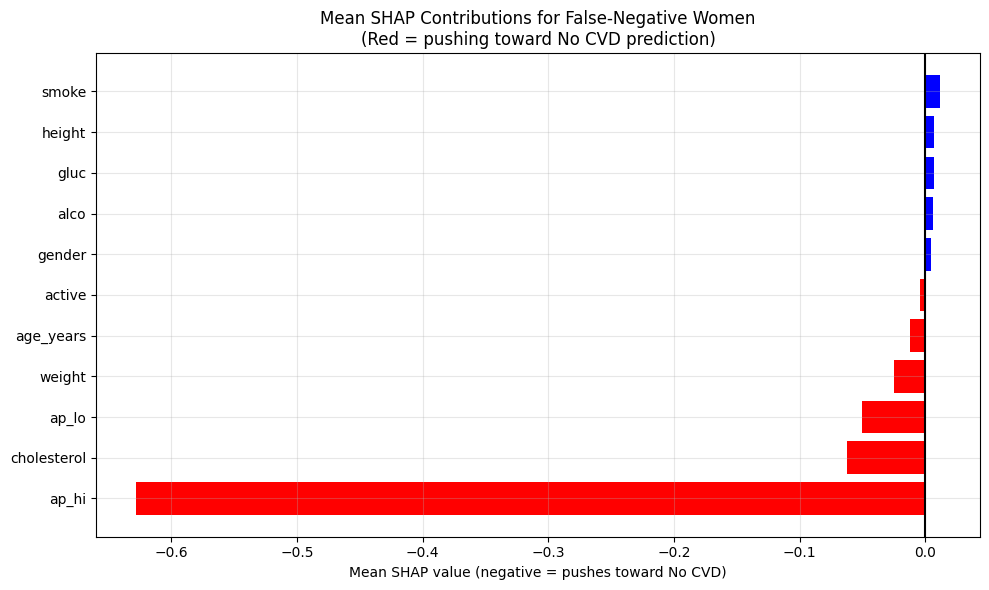

In [8]:
fn_mean_shap = fn_shap.mean().sort_values()
colors = ["red" if v < 0 else "blue" for v in fn_mean_shap.values]

plt.figure(figsize=(10, 6))
plt.barh(fn_mean_shap.index, fn_mean_shap.values, color=colors)
plt.axvline(x=0, color="black", linewidth=1.5)
plt.xlabel("Mean SHAP value (negative = pushes toward No CVD)")
plt.title("Mean SHAP Contributions for False-Negative Women\n(Red = pushing toward No CVD prediction)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. SHAP Dependence: Systolic BP (Women & Men)

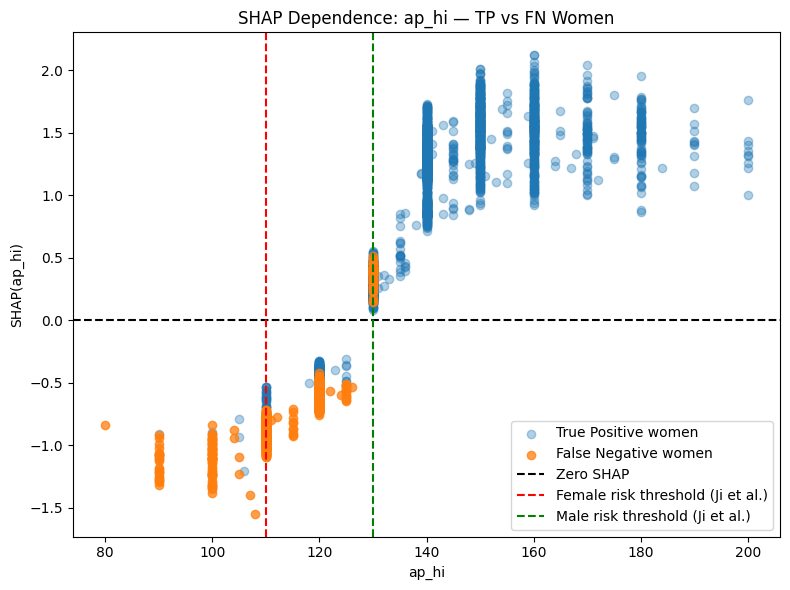

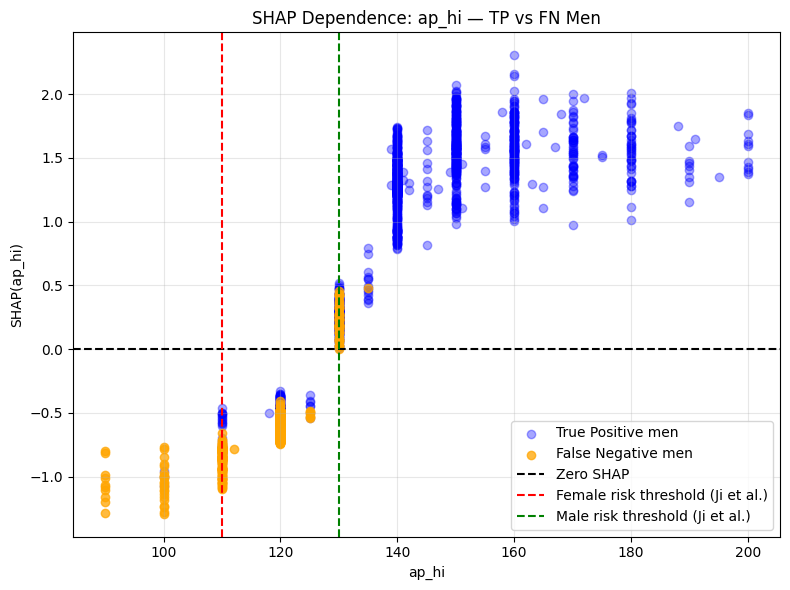

In [9]:
feature  = "ap_hi"
feat_idx = X_test.columns.get_loc(feature)

fn_mask_female_bool = shap_female_df["false_negative"] == 1
tp_mask_female_bool = shap_female_df["true_positive"]  == 1

# Women
plt.figure(figsize=(8, 6))
plt.scatter(X_test_female.loc[tp_mask_female_bool, feature],
            sv_female.values[tp_mask_female_bool, feat_idx],
            alpha=0.35, label="True Positive women")
plt.scatter(X_test_female.loc[fn_mask_female_bool, feature],
            sv_female.values[fn_mask_female_bool, feat_idx],
            alpha=0.75, label="False Negative women")
plt.axhline(y=0,   color="black", linestyle="--", linewidth=1.5, label="Zero SHAP")
plt.axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male risk threshold (Ji et al.)")
plt.xlabel(feature)
plt.ylabel(f"SHAP({feature})")
plt.title(f"SHAP Dependence: {feature} — TP vs FN Women")
plt.legend()
plt.tight_layout()
plt.show()

# Men
sv_male = explainer(X_test_male)

male_positions   = test_df["gender"].values == 1
X_male_reset     = X_test_male.reset_index(drop=True)
fn_mask_male_sub = fn_mask_male[male_positions]
tp_mask_male_sub = tp_mask_male[male_positions]

plt.figure(figsize=(8, 6))
plt.scatter(X_male_reset.loc[tp_mask_male_sub, feature],
            sv_male.values[tp_mask_male_sub, feat_idx],
            alpha=0.35, label="True Positive men", color="blue")
plt.scatter(X_male_reset.loc[fn_mask_male_sub, feature],
            sv_male.values[fn_mask_male_sub, feat_idx],
            alpha=0.75, label="False Negative men", color="orange")
plt.axhline(y=0,   color="black", linestyle="--", linewidth=1.5, label="Zero SHAP")
plt.axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female risk threshold (Ji et al.)")
plt.axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male risk threshold (Ji et al.)")
plt.xlabel(feature)
plt.ylabel(f"SHAP({feature})")
plt.title(f"SHAP Dependence: {feature} — TP vs FN Men")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. KDE Distributions: FN vs TP (Women & Men)

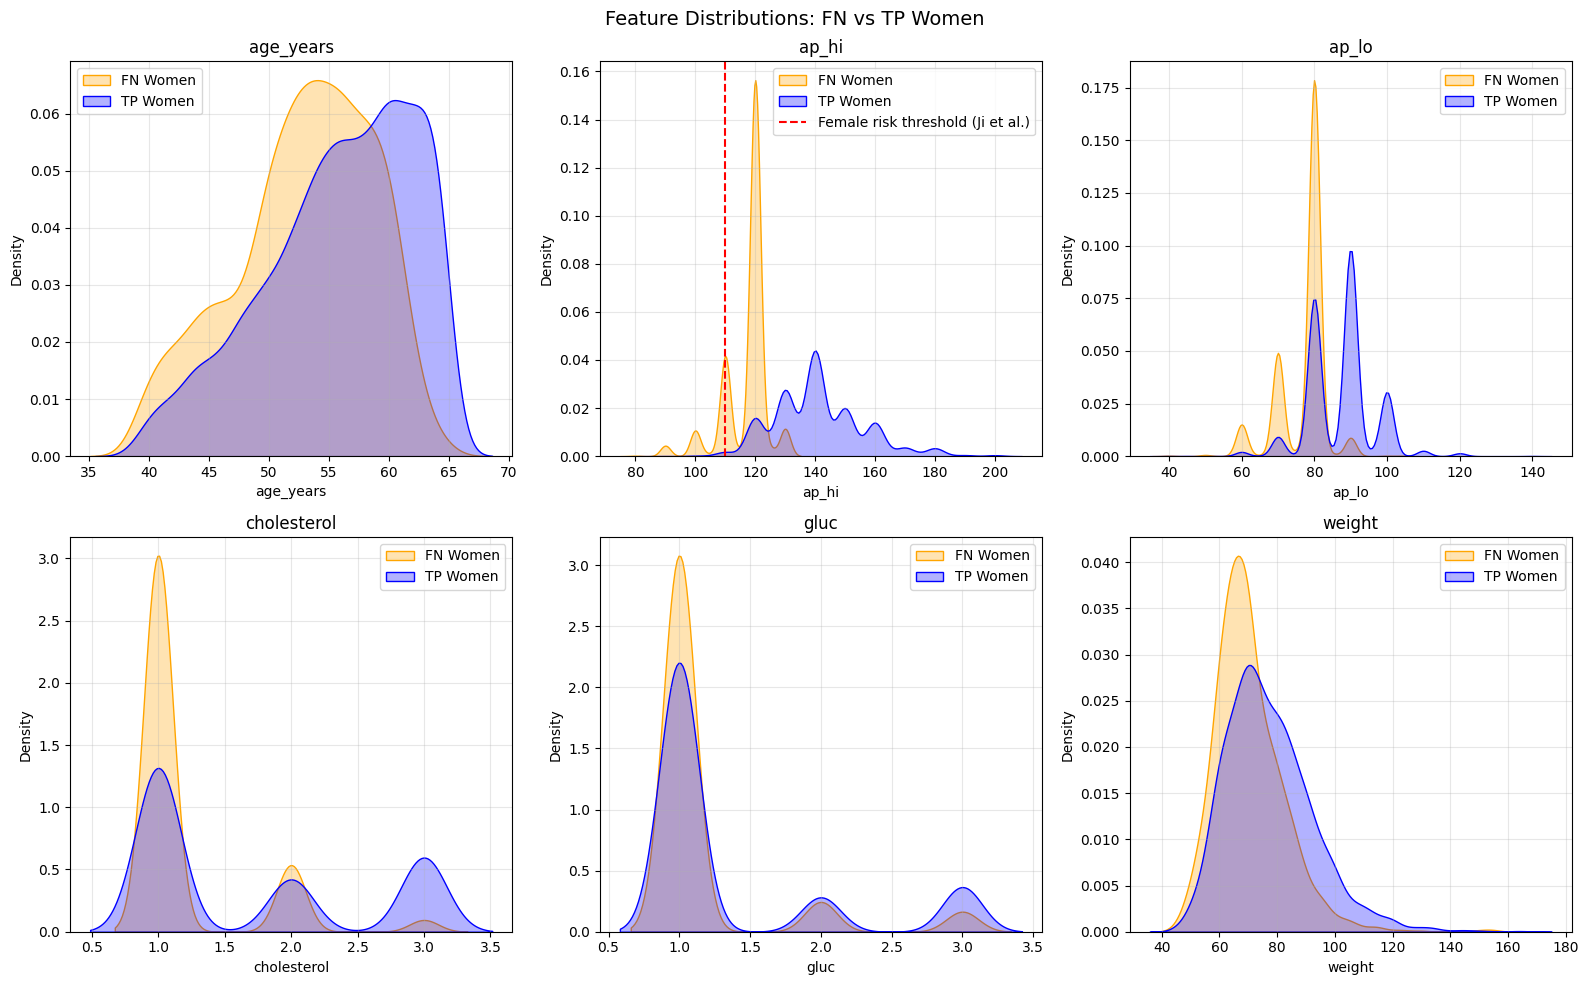

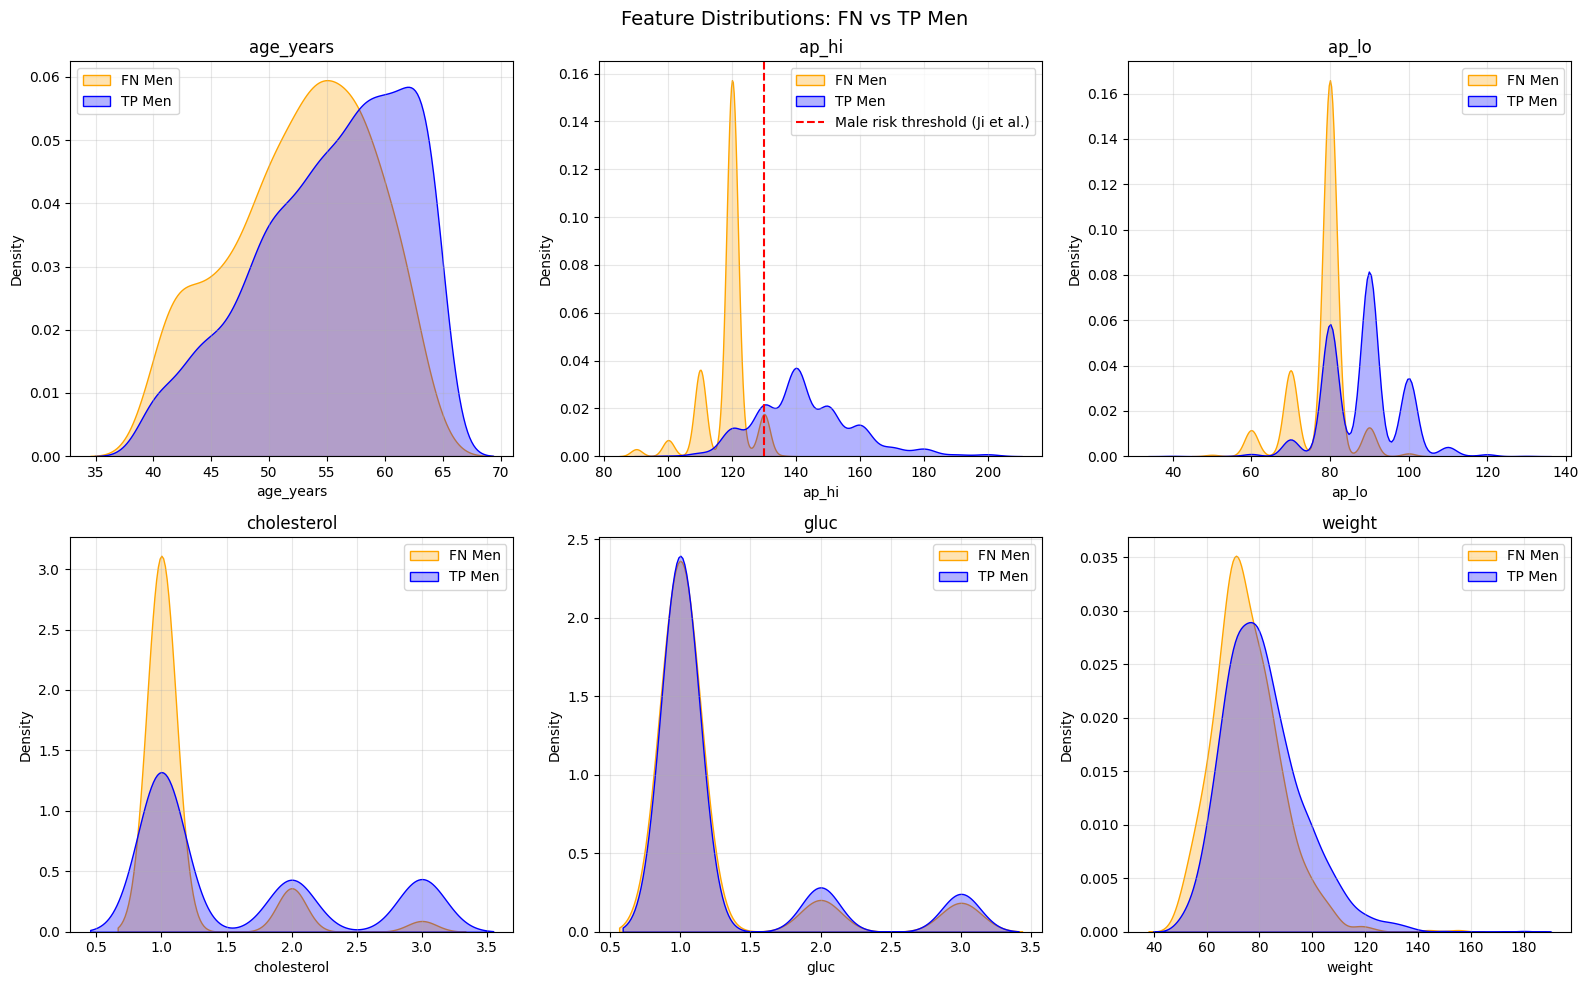

In [10]:
features_to_plot = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc", "weight"]

for fn_grp, tp_grp, suffix in [(fn_women, tp_women, "Women"), (fn_men, tp_men, "Men")]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    for idx, feat in enumerate(features_to_plot):
        sns.kdeplot(fn_grp[feat], ax=axes[idx], label=f"FN {suffix}", color="orange", fill=True, alpha=0.3)
        sns.kdeplot(tp_grp[feat], ax=axes[idx], label=f"TP {suffix}", color="blue",   fill=True, alpha=0.3)
        axes[idx].set_title(feat)
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)
        if feat == "ap_hi":
            threshold = 110 if suffix == "Women" else 130
            label     = "Female risk threshold (Ji et al.)" if suffix == "Women" else "Male risk threshold (Ji et al.)"
            axes[idx].axvline(x=threshold, color="red", linestyle="--", linewidth=1.5, label=label)
            axes[idx].legend()
    plt.suptitle(f"Feature Distributions: FN vs TP {suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

## 11. KDE: TN vs FN — Age & Systolic BP (Women & Men)

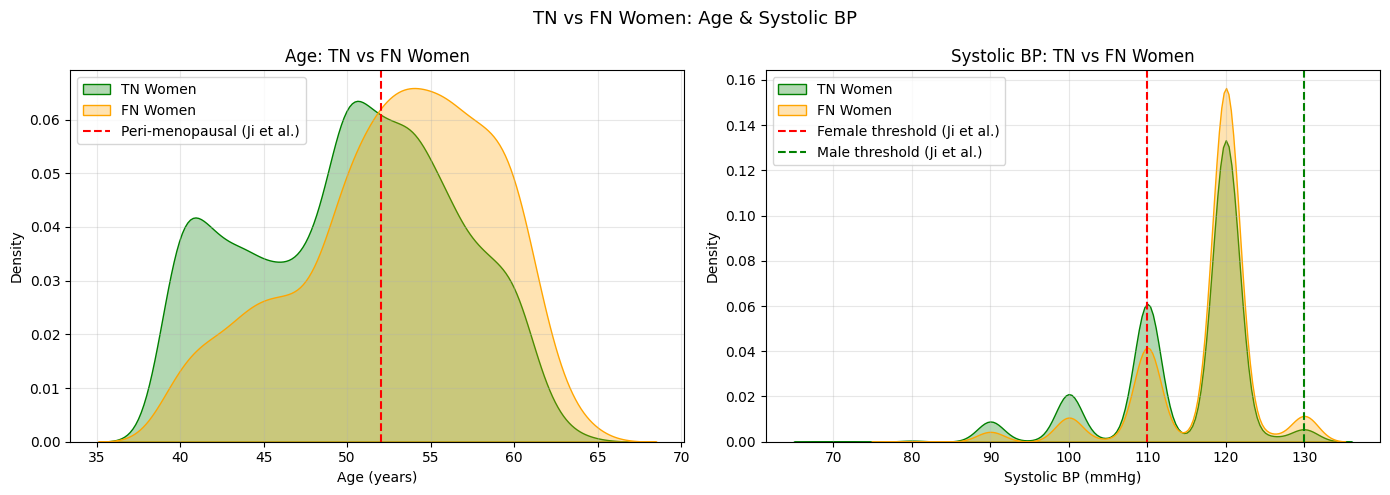

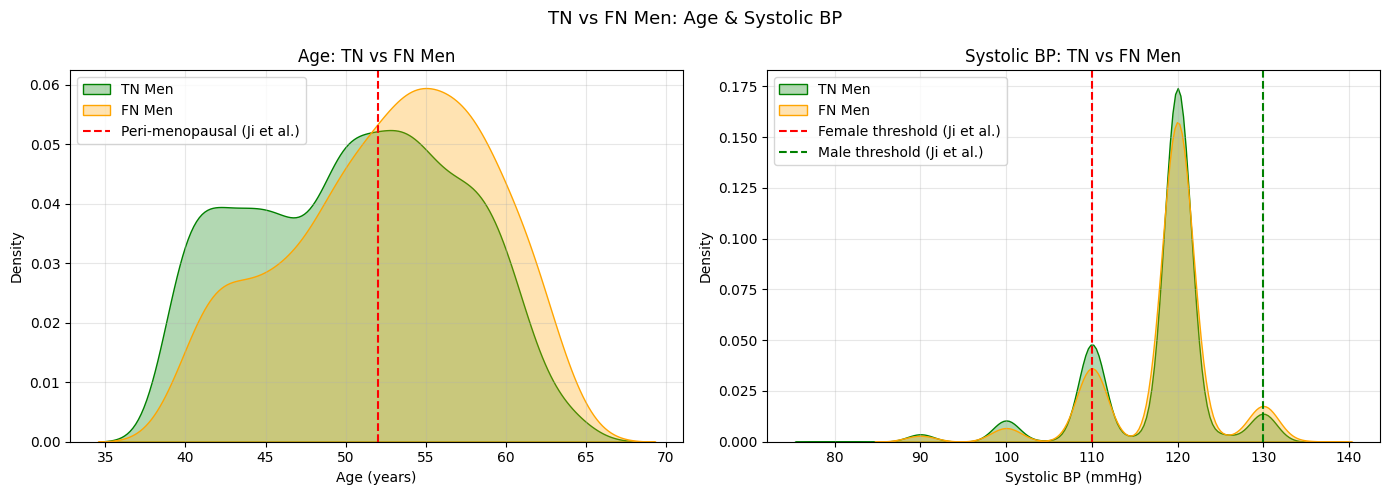

In [11]:
for tn_grp, fn_grp, suffix in [(tn_women, fn_women, "Women"), (tn_men, fn_men, "Men")]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Age
    sns.kdeplot(tn_grp["age_years"], ax=axes[0], color="green",  fill=True, alpha=0.3, label=f"TN {suffix}")
    sns.kdeplot(fn_grp["age_years"], ax=axes[0], color="orange", fill=True, alpha=0.3, label=f"FN {suffix}")
    axes[0].axvline(x=52, color="red", linestyle="--", linewidth=1.5, label="Peri-menopausal (Ji et al.)")
    axes[0].set_title(f"Age: TN vs FN {suffix}")
    axes[0].set_xlabel("Age (years)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Systolic BP
    sns.kdeplot(tn_grp["ap_hi"], ax=axes[1], color="green",  fill=True, alpha=0.3, label=f"TN {suffix}")
    sns.kdeplot(fn_grp["ap_hi"], ax=axes[1], color="orange", fill=True, alpha=0.3, label=f"FN {suffix}")
    axes[1].axvline(x=110, color="red",   linestyle="--", linewidth=1.5, label="Female threshold (Ji et al.)")
    axes[1].axvline(x=130, color="green", linestyle="--", linewidth=1.5, label="Male threshold (Ji et al.)")
    axes[1].set_title(f"Systolic BP: TN vs FN {suffix}")
    axes[1].set_xlabel("Systolic BP (mmHg)")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(f"TN vs FN {suffix}: Age & Systolic BP", fontsize=13)
    plt.tight_layout()
    plt.show()

## 12. Violin Plots: TN vs FN Women

C:\Users\kavis\AppData\Local\Temp\ipykernel_5208\210946985.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="group", y=feat,
C:\Users\kavis\AppData\Local\Temp\ipykernel_5208\210946985.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="group", y=feat,
C:\Users\kavis\AppData\Local\Temp\ipykernel_5208\210946985.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined, x="group", y=feat,
C:\Users\kavis\AppData\Local\Temp\ipykernel_5208\210946985.py:11: FutureWarning: 

Passing `palette`

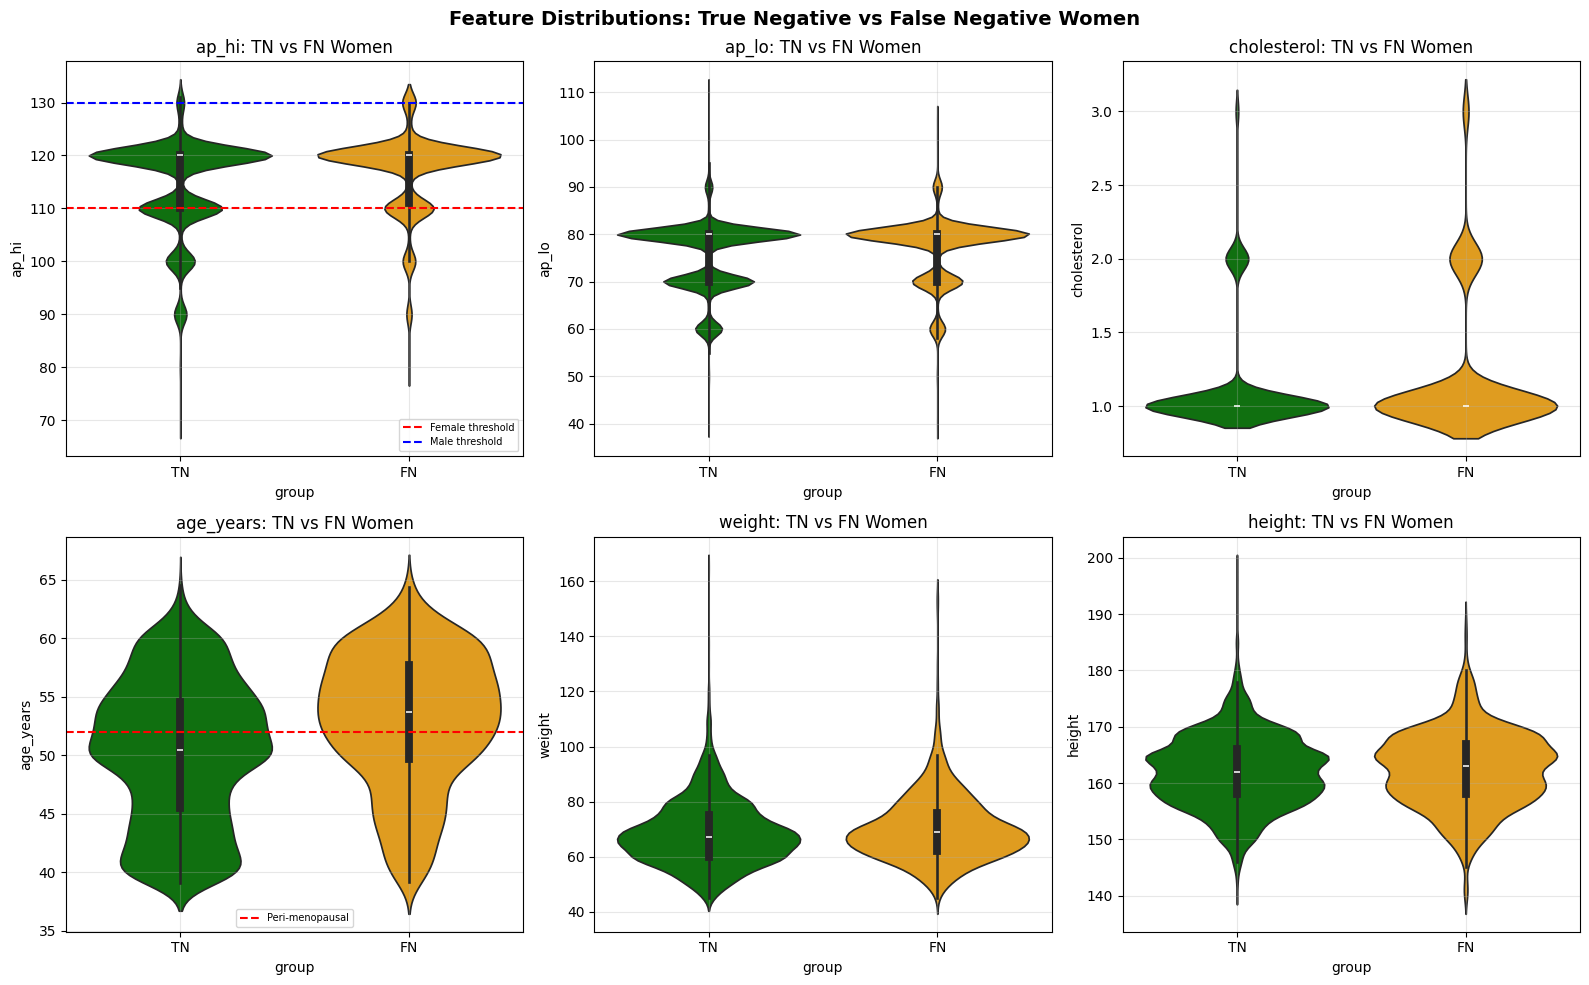

In [12]:
violin_features = ["ap_hi", "ap_lo", "cholesterol", "age_years", "weight", "height"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(violin_features):
    tn_plot = tn_women[[feat]].copy(); tn_plot["group"] = "TN"
    fn_plot = fn_women[[feat]].copy(); fn_plot["group"] = "FN"
    combined = pd.concat([tn_plot, fn_plot])

    sns.violinplot(data=combined, x="group", y=feat,
                   palette={"TN": "green", "FN": "orange"}, ax=axes[idx])

    if feat == "ap_hi":
        axes[idx].axhline(y=110, color="red",  linestyle="--", linewidth=1.5, label="Female threshold")
        axes[idx].axhline(y=130, color="blue", linestyle="--", linewidth=1.5, label="Male threshold")
        axes[idx].legend(fontsize=7)
    if feat == "age_years":
        axes[idx].axhline(y=52, color="red", linestyle="--", linewidth=1.5, label="Peri-menopausal")
        axes[idx].legend(fontsize=7)

    axes[idx].set_title(f"{feat}: TN vs FN Women")
    axes[idx].grid(alpha=0.3)

plt.suptitle("Feature Distributions: True Negative vs False Negative Women",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Categorical Feature Distributions: TN vs FN Women

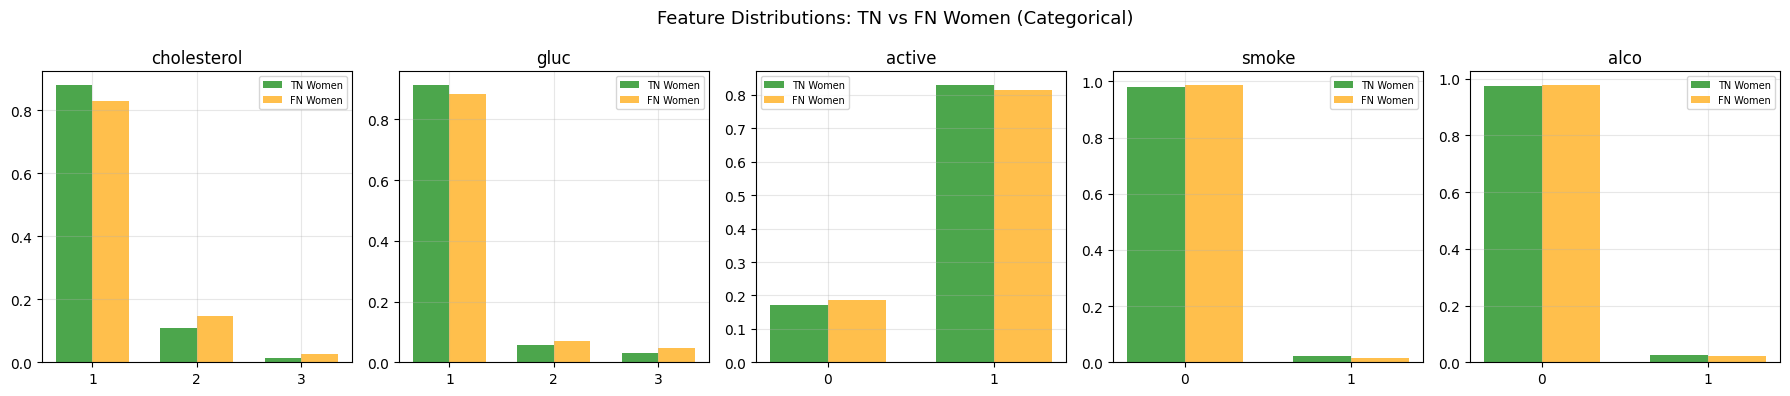

In [13]:
cat_features = ["cholesterol", "gluc", "active", "smoke", "alco"]

fig, axes = plt.subplots(1, len(cat_features), figsize=(18, 4))

for ax, feat in zip(axes, cat_features):
    tn_counts = tn_women[feat].value_counts(normalize=True).sort_index()
    fn_counts = fn_women[feat].value_counts(normalize=True).sort_index()
    x = range(len(tn_counts))
    width = 0.35
    ax.bar([i - width/2 for i in x], tn_counts.values, width, label="TN Women", color="green",  alpha=0.7)
    ax.bar([i + width/2 for i in x], fn_counts.values, width, label="FN Women", color="orange", alpha=0.7)
    ax.set_xticks(list(x))
    ax.set_xticklabels(tn_counts.index)
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("Feature Distributions: TN vs FN Women (Categorical)", fontsize=13)
plt.tight_layout()
plt.show()

## 14. TN Women — Clinical Risk Zone Analysis

In [14]:
clinically_at_risk = tn_women[tn_women["ap_hi"] >= 110]
peri_menopausal    = clinically_at_risk[clinically_at_risk["age_years"] >= 45]

print(f"TN women total               : {len(tn_women)}")
print(f"TN women with BP >= 110 mmHg : {len(clinically_at_risk)} ({len(clinically_at_risk)/len(tn_women)*100:.1f}%)")
print(f"  Of those, age >= 45        : {len(peri_menopausal)} ({len(peri_menopausal)/len(tn_women)*100:.1f}%)")
print(f"\nTN women mean age : {tn_women['age_years'].mean():.1f}")
print(f"FN women mean age : {fn_women['age_years'].mean():.1f}")
print(f"TN women age >= 45: {(tn_women['age_years'] >= 45).sum()} ({(tn_women['age_years'] >= 45).mean()*100:.1f}%)")
print(f"FN women age >= 45: {(fn_women['age_years'] >= 45).sum()} ({(fn_women['age_years'] >= 45).mean()*100:.1f}%)")
print(f"\nTN men with BP >= 130 mmHg: {(tn_men['ap_hi'] >= 130).sum()} ({(tn_men['ap_hi'] >= 130).mean()*100:.1f}%)")
print(f"FN men with BP >= 130 mmHg: {(fn_men['ap_hi'] >= 130).sum()} ({(fn_men['ap_hi'] >= 130).mean()*100:.1f}%)")

print("\nTN women in clinical risk zone vs not:")
print(pd.DataFrame({
    "At risk (BP>=110)":    clinically_at_risk[["age_years", "ap_hi", "cholesterol"]].mean(),
    "Not at risk (BP<110)": tn_women[tn_women["ap_hi"] < 110][["age_years", "ap_hi", "cholesterol"]].mean()
}).round(2))

TN women total               : 3474
TN women with BP >= 110 mmHg : 3004 (86.5%)
  Of those, age >= 45        : 2341 (67.4%)

TN women mean age : 50.2
FN women mean age : 52.9
TN women age >= 45: 2632 (75.8%)
FN women age >= 45: 1160 (88.1%)

TN men with BP >= 130 mmHg: 97 (5.3%)
FN men with BP >= 130 mmHg: 61 (8.0%)

TN women in clinical risk zone vs not:
             At risk (BP>=110)  Not at risk (BP<110)
age_years                50.55                 48.26
ap_hi                   117.30                 96.92
cholesterol               1.13                  1.18


## 15. SHAP Waterfall: FN Woman vs Nearest Matched Male

c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Feature comparison (FN woman vs matched male):
              FN Woman Matched Male
age_years    53.686516    53.497604
ap_hi              120          120
cholesterol          1            1
weight            69.0         69.0


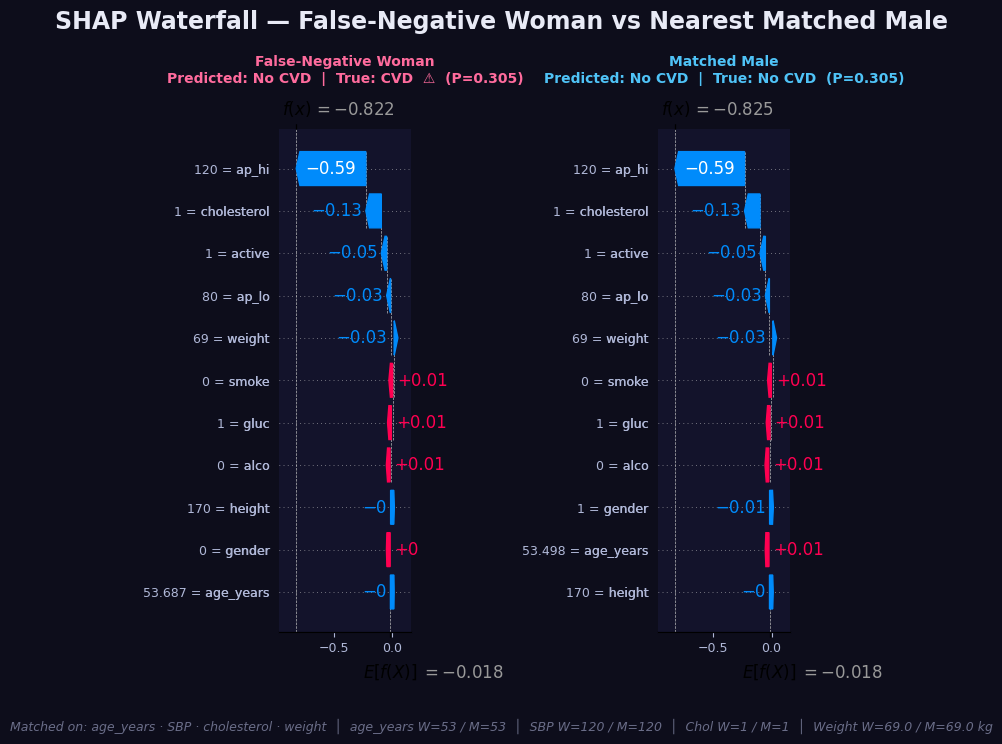


Top SHAP drivers (sorted by |woman SHAP|):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi     -0.5943    -0.5943     +0.0000
cholesterol     -0.1322    -0.1322     -0.0000
     active     -0.0455    -0.0456     +0.0001
      ap_lo     -0.0338    -0.0343     +0.0005
     weight     -0.0304    -0.0295     -0.0008
      smoke     +0.0130    +0.0130     +0.0000
       gluc     +0.0114    +0.0114     +0.0000
       alco     +0.0104    +0.0104     -0.0000
     height     -0.0047    -0.0046     -0.0001
     gender     +0.0038    -0.0073     +0.0111


In [15]:
MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]

# Select most representative FN woman (closest to median profile)
fn_std    = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median = fn_women[MATCHING_FEATURES].median()
distances = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# Find nearest male (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("Feature comparison (FN woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# SHAP values
woman_df = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df  = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman = explainer(woman_df)
sv_male  = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# Waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  \u26a0\ufe0f  (P={prob_woman:.3f})", accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"],
                      fontsize=10, fontweight="bold", pad=12)

fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age_years \u00b7 SBP \u00b7 cholesterol \u00b7 weight  \u2502  "
         f"age_years W={int(rep_woman['age_years'])} / M={int(rep_male['age_years'])}  \u2502  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  \u2502  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  \u2502  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))

## 16. SHAP Counterfactual: Gender Swap

height         True
weight         True
ap_hi          True
ap_lo          True
cholesterol    True
gluc           True
smoke          True
alco           True
active         True
age_years      True
dtype: bool


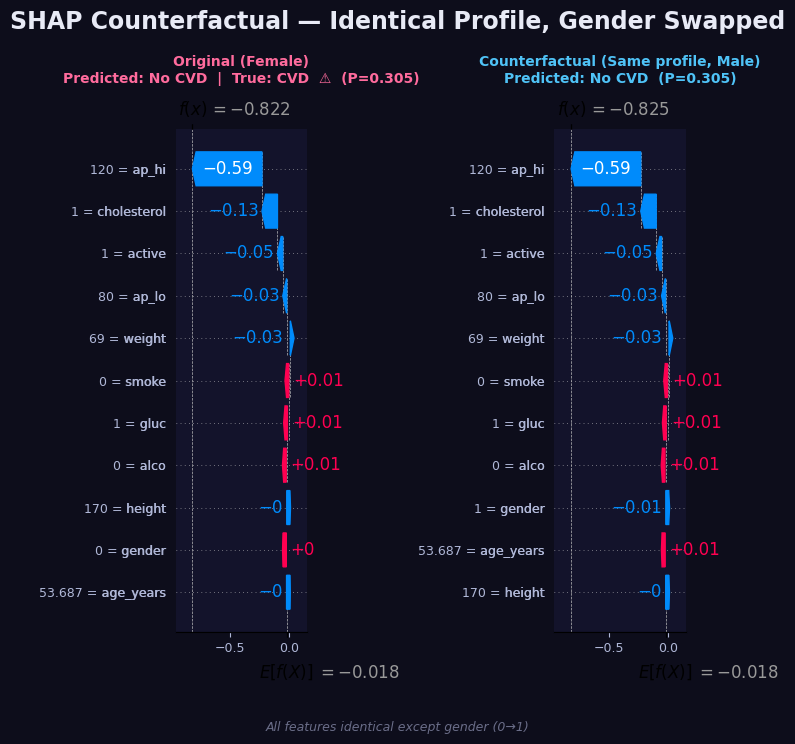


Original (Female) CVD probability     : 0.305
Counterfactual (Male) CVD probability : 0.305
Probability difference (M-F)          : -0.001


In [20]:
woman_counterfactual = woman_df.copy()
woman_counterfactual["gender"] = 1  # flip to male
print((woman_df.drop(columns="gender") == woman_counterfactual.drop(columns="gender")).all())

sv_counterfactual   = explainer(woman_counterfactual)
prob_counterfactual = model.predict_proba(woman_counterfactual.values)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="Original (Female)",
         subtitle=f"Predicted: No CVD  |  True: CVD  \u26a0\ufe0f  (P={prob_woman:.3f})", accent="#ff6b9d"),
    dict(sv=sv_counterfactual, ax=axes[1], title="Counterfactual (Same profile, Male)",
         subtitle=f"Predicted: {'CVD' if model.predict(woman_counterfactual.values)[0]==1 else 'No CVD'}  (P={prob_counterfactual:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"],
                      fontsize=10, fontweight="bold", pad=12)

fig.suptitle("SHAP Counterfactual — Identical Profile, Gender Swapped",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01, "All features identical except gender (0\u21921)",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_counterfactual_gender.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

print(f"\nOriginal (Female) CVD probability     : {prob_woman:.3f}")
print(f"Counterfactual (Male) CVD probability : {prob_counterfactual:.3f}")
print(f"Probability difference (M-F)          : {prob_counterfactual - prob_woman:+.3f}")